---
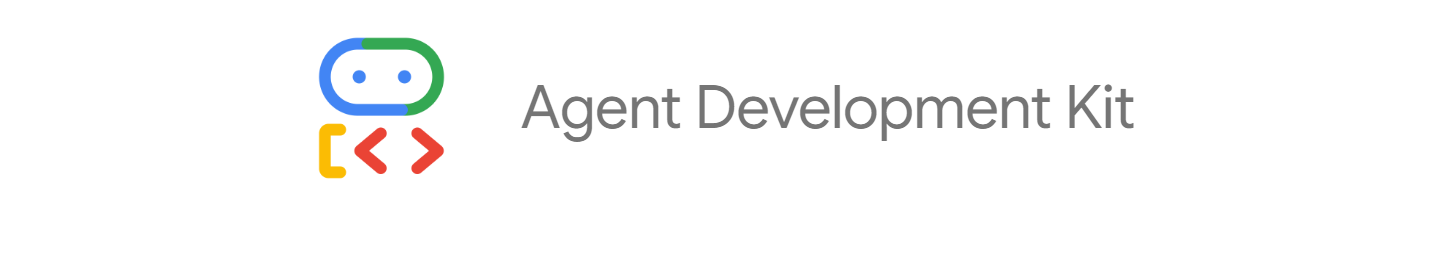

---

# Context in ADK

---


## What are Context
In the **Agent Development Kit (ADK)**, "`context`" refers to the crucial bundle of information available to your agent and its tools during specific operations. Think of it as the necessary background knowledge and resources needed to handle a current task or conversation turn effectively.

Agents often need more than just the latest user message to perform well. Context is essential because it enables:
1. **Maintaining State:** Remembering details across multiple steps in a conversation (e.g., user preferences, previous calculations, items in a shopping cart). This is primarily managed through session state.
2. **Passing Data:** Sharing information discovered or generated in one step (like an LLM call or a tool execution) with subsequent steps. Session state is key here too.
3. **Accessing Services:** Interacting with framework capabilities like:
    - **Artifact Storage:** Saving or loading files or data blobs (like PDFs, images, configuration files) associated with the session.
    - **Memory:** Searching for relevant information from past interactions or external knowledge sources connected to the user.
    - **Authentication:** Requesting and retrieving credentials needed by tools to access external APIs securely.
4. **Identity and Tracking:** Knowing which agent is currently running (agent.name) and uniquely identifying the current request-response cycle (invocation_id) for logging and debugging.
5. **Tool-Specific Actions:** Enabling specialized operations within tools, such as requesting authentication or searching memory, which require access to the current interaction's details.

The central piece holding all this information together for a single, complete user-request-to-final-response cycle (an **invocation**) is the InvocationContext. However, you typically won't create or manage this object directly. The ADK framework creates it when an invocation starts (e.g., via runner.run_async) and passes the relevant contextual information implicitly to your agent code, callbacks, and tools.

```Python
# Conceptual Pseudocode: How the framework provides context (Internal Logic)

# runner = Runner(agent=my_root_agent, session_service=..., artifact_service=...)
# user_message = types.Content(...)
# session = session_service.get_session(...) # Or create new

# --- Inside runner.run_async(...) ---
# 1. Framework creates the main context for this specific run
# invocation_context = InvocationContext(
#     invocation_id="unique-id-for-this-run",
#     session=session,
#     user_content=user_message,
#     agent=my_root_agent, # The starting agent
#     session_service=session_service,
#     artifact_service=artifact_service,
#     memory_service=memory_service,
#     # ... other necessary fields ...
# )
#
# 2. Framework calls the agent's run method, passing the context implicitly
#    (The agent's method signature will receive it, e.g., runAsyncImpl(InvocationContext invocationContext))
# await my_root_agent.run_async(invocation_context)
#   --- End Internal Logic ---
#
# As a developer, you work with the context objects provided in method arguments.
```
<br>

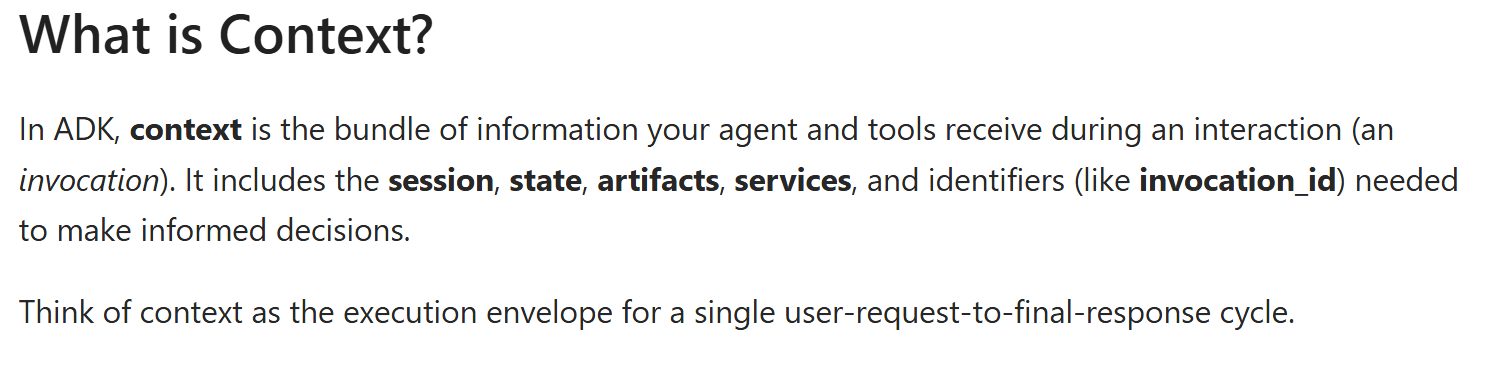 <br> 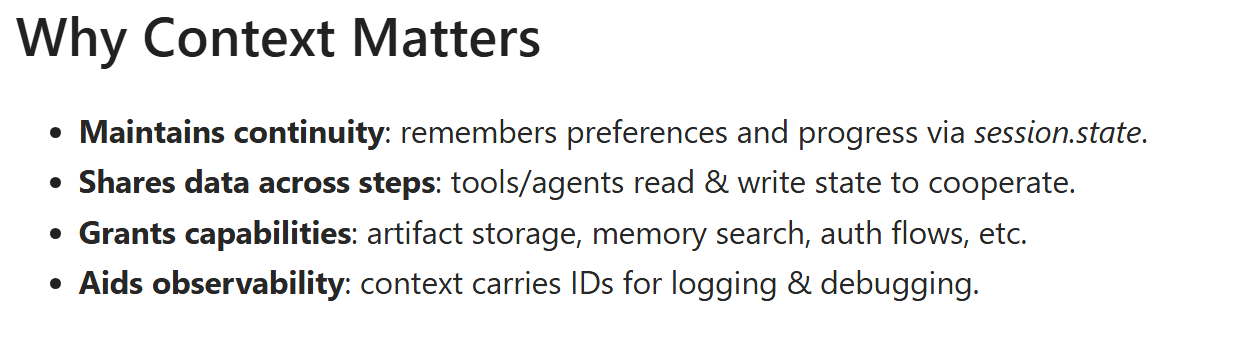 <br><br>

### `Context-Flow (High-Level Diagram)`
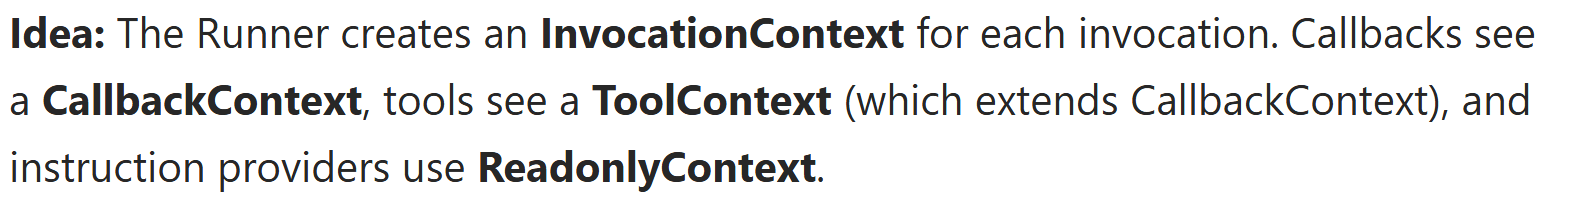

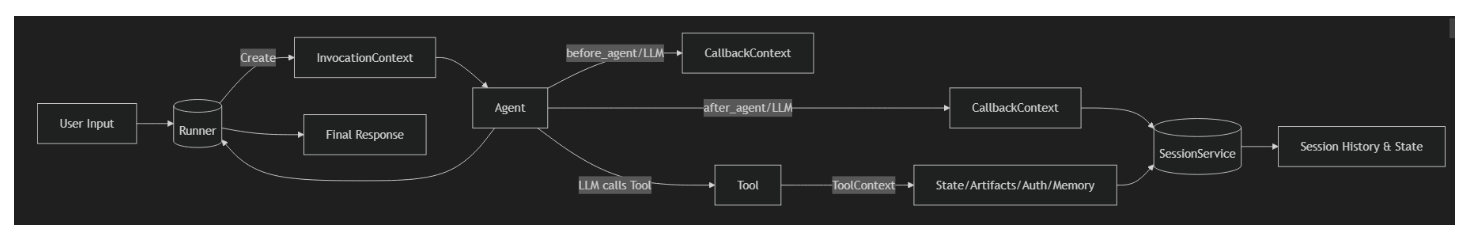

---


## The Different types of Context
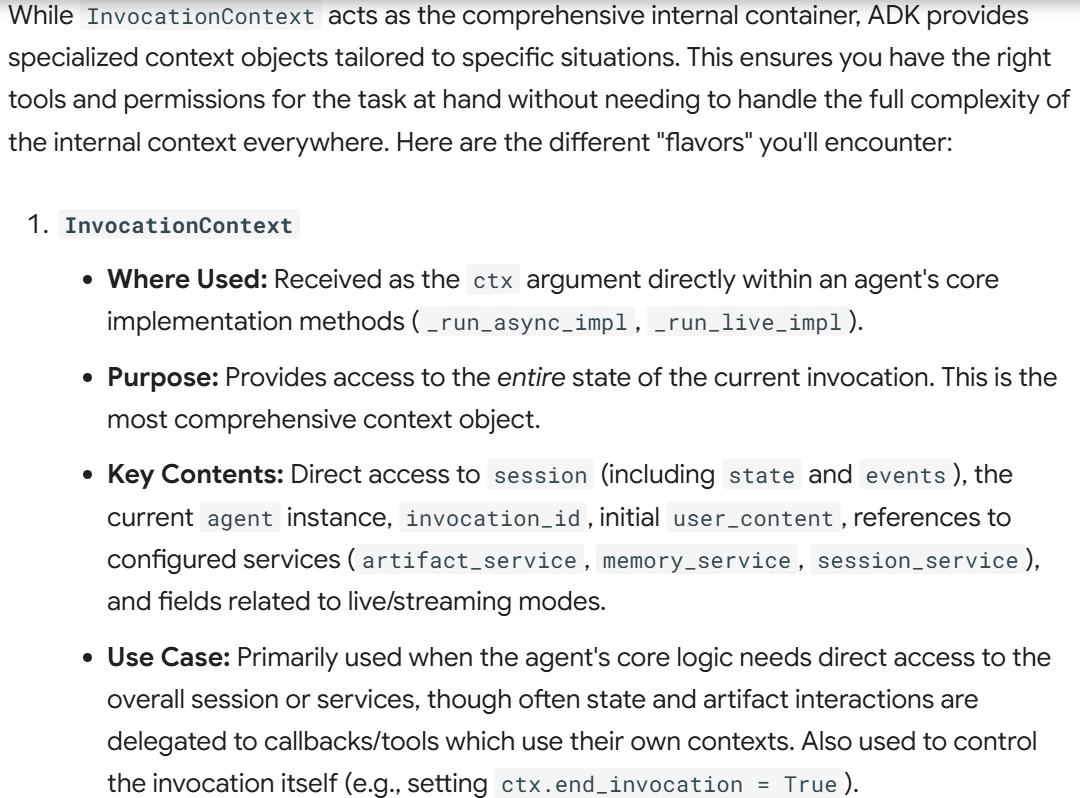

```Python
# Pseudocode: Agent implementation receiving InvocationContext
from google.adk.agents import BaseAgent
from google.adk.agents.invocation_context import InvocationContext
from google.adk.events import Event
from typing import AsyncGenerator

class MyAgent(BaseAgent):
    async def _run_async_impl(self, ctx: InvocationContext) -> AsyncGenerator[Event, None]:
        # Direct access example
        agent_name = ctx.agent.name
        session_id = ctx.session.id
        print(f"Agent {agent_name} running in session {session_id} for invocation {ctx.invocation_id}")
        # ... agent logic using ctx ...
        yield # ... event ...
```
<br>

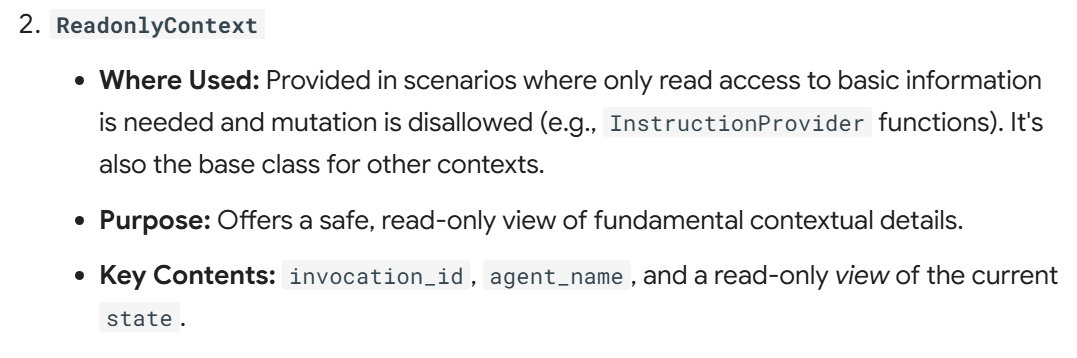

```Python
# Pseudocode: Instruction provider receiving ReadonlyContext
from google.adk.agents.readonly_context import ReadonlyContext

def my_instruction_provider(context: ReadonlyContext) -> str:
    # Read-only access example
    user_tier = context.state().get("user_tier", "standard") # Can read state
    # context.state['new_key'] = 'value' # This would typically cause an error or be ineffective
    return f"Process the request for a {user_tier} user."
```
<br>

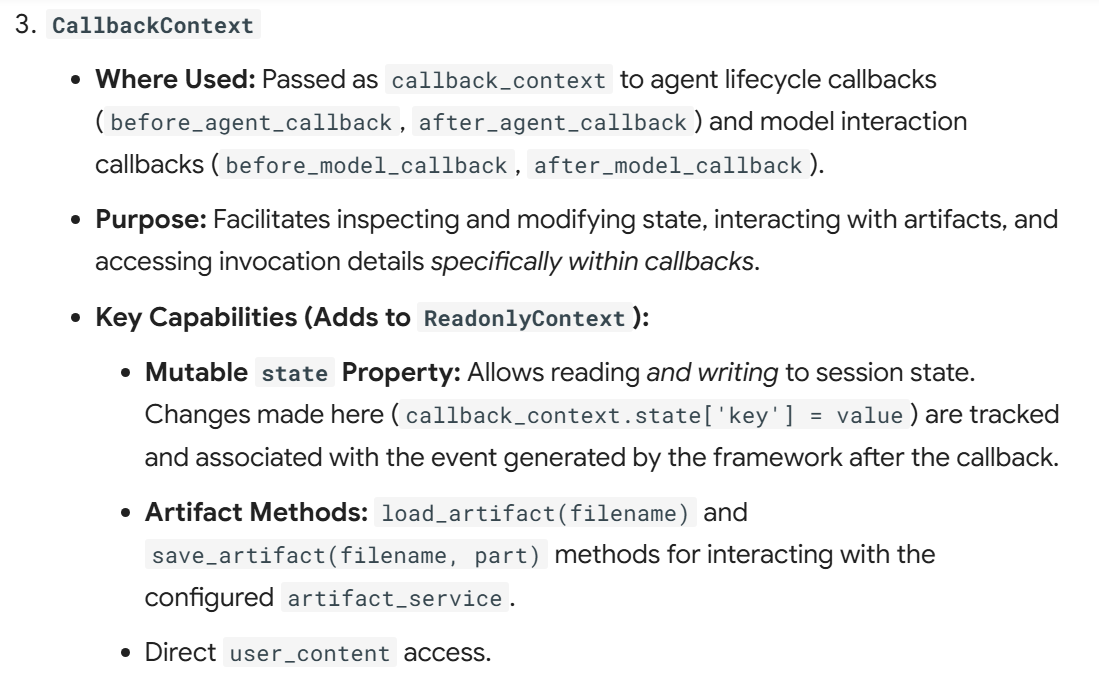

```Python
# Pseudocode: Callback receiving CallbackContext
from google.adk.agents.callback_context import CallbackContext
from google.adk.models import LlmRequest
from google.genai import types
from typing import Optional

def my_before_model_cb(callback_context: CallbackContext, request: LlmRequest) -> Optional[types.Content]:
    # Read/Write state example
    call_count = callback_context.state.get("model_calls", 0)
    callback_context.state["model_calls"] = call_count + 1 # Modify state

    # Optionally load an artifact
    # config_part = callback_context.load_artifact("model_config.json")
    print(f"Preparing model call #{call_count + 1} for invocation {callback_context.invocation_id}")
    return None # Allow model call to proceed
```
<br>

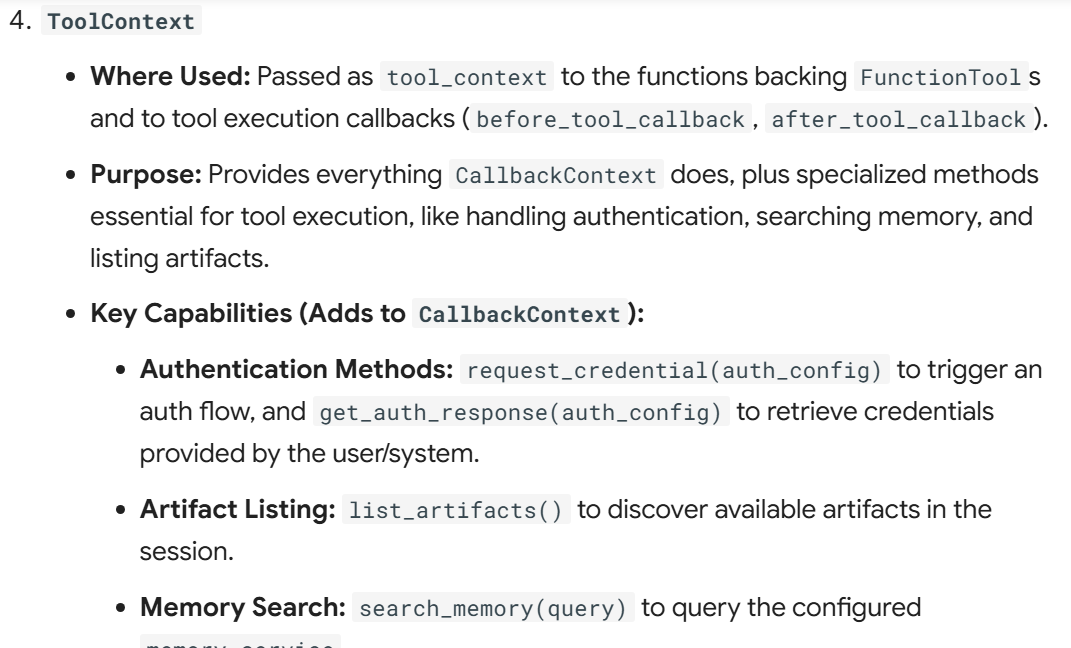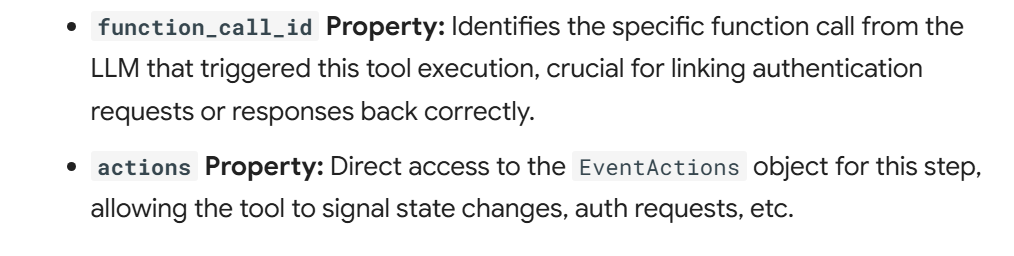

```Python
# Pseudocode: Tool function receiving ToolContext
from google.adk.tools import ToolContext
from typing import Dict, Any

# Assume this function is wrapped by a FunctionTool
def search_external_api(query: str, tool_context: ToolContext) -> Dict[str, Any]:
    api_key = tool_context.state.get("api_key")
    if not api_key:
        # Define required auth config
        # auth_config = AuthConfig(...)
        # tool_context.request_credential(auth_config) # Request credentials
        # Use the 'actions' property to signal the auth request has been made
        # tool_context.actions.requested_auth_configs[tool_context.function_call_id] = auth_config
        return {"status": "Auth Required"}

    # Use the API key...
    print(f"Tool executing for query '{query}' using API key. Invocation: {tool_context.invocation_id}")

    # Optionally search memory or list artifacts
    # relevant_docs = tool_context.search_memory(f"info related to {query}")
    # available_files = tool_context.list_artifacts()

    return {"result": f"Data for {query} fetched."}
```
<br>

> Understanding these different context objects and when to use them is key to effectively managing state, accessing services, and controlling the flow of your ADK application. The next section will detail common tasks you can perform using these contexts.

----
### `Types of Context`
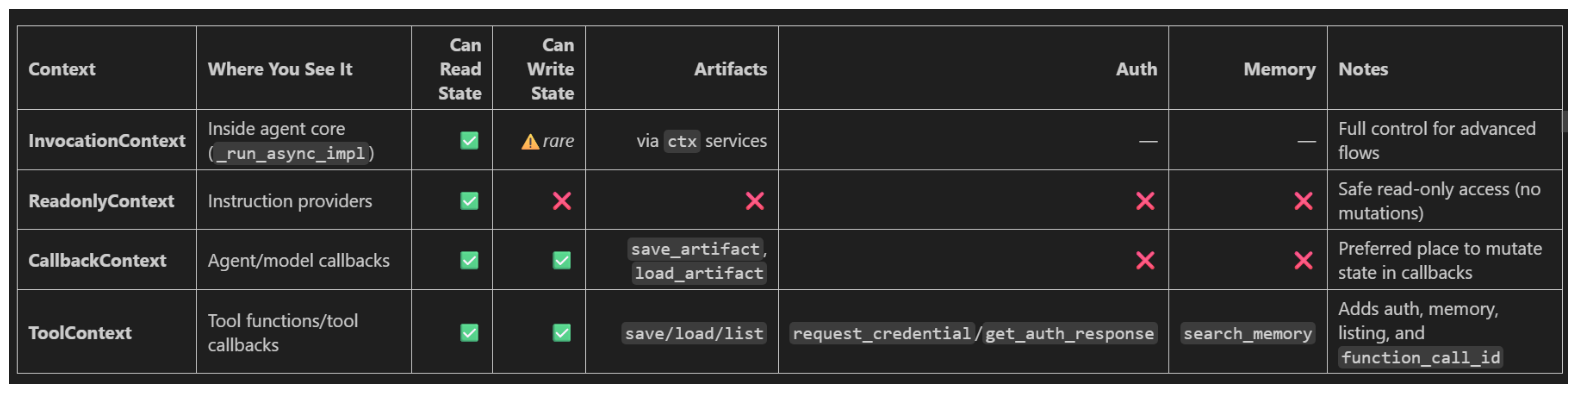

----